# 01 — HCW Dynamics & Conjunction Scenario

Sets up a representative LEO spacecraft-debris conjunction scenario using
Hill-Clohessy-Wiltshire (HCW) linearized relative dynamics. This notebook:

1. Propagates the uncontrolled relative trajectory to find TCA
2. Visualizes the relative motion in RTN space
3. Shows the collision sphere (hard-body radius) at TCA
4. Serves as the foundation for BRT computation in notebook 02


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from spacecraft_brt.dynamics.hcw import (
    propagate_hcw,
    separation_distance,
    time_of_closest_approach,
)
from spacecraft_brt.dynamics.scenario import make_crossing_conjunction

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Define Conjunction Scenario

In [11]:
# Build a representative LEO crossing conjunction
scenario = make_crossing_conjunction(
    altitude_km=550.0,
    miss_distance=1.0,
    relative_velocity_mps=7000.0,
    hard_body_r=10.0,
)
print(scenario.summary())

Scenario: LEO 550km crossing-conjunction
  SMA:          6921.0 km
  Mean motion:  1.0965 mrad/s
  T horizon:    23.88 hr
  TCA:          23.876 hr (85951.9 s)
  Miss distance:1000.0 m
  Hard-body R:  10.0 m
  x0:           [1.00000000e+03 5.65486678e+05 1.12120583e-07 2.85023015e-13
 1.48763994e-12 7.00000000e+03]



## 2. Propagate Relative Trajectory

In [12]:
t_eval, states = scenario.propagate(n_steps=5000)
distances = separation_distance(states)
t_tca, d_tca = time_of_closest_approach(states, t_eval)

print(f"TCA at t = {t_tca:.1f} s ({t_tca/3600:.3f} hr)")
print(f"Miss distance = {d_tca:.2f} m")
print(f"Hard-body radius = {scenario.hard_body_r:.1f} m")
print(f"Collision predicted: {d_tca < scenario.hard_body_r}")

TCA at t = 85951.9 s (23.876 hr)
Miss distance = 1000.00 m
Hard-body radius = 10.0 m
Collision predicted: False


## 3. Visualize — Separation Distance vs Time

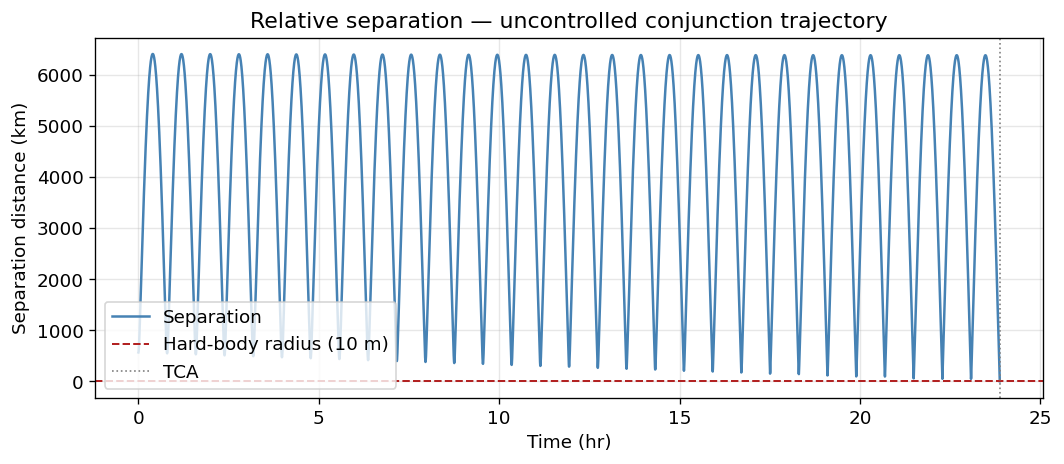

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(t_eval / 3600, distances / 1e3, 'steelblue', linewidth=1.5, label='Separation')
ax.axhline(scenario.hard_body_r / 1e3, color='firebrick', linestyle='--',
           linewidth=1.2, label=f'Hard-body radius ({scenario.hard_body_r:.0f} m)')
ax.axvline(t_tca / 3600, color='gray', linestyle=':', linewidth=1, label='TCA')

ax.set_xlabel('Time (hr)')
ax.set_ylabel('Separation distance (km)')
ax.set_title('Relative separation — uncontrolled conjunction trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/01_separation_distance.png', dpi=150)
plt.show()

## 4. Visualize — RTN Trajectory (3D)

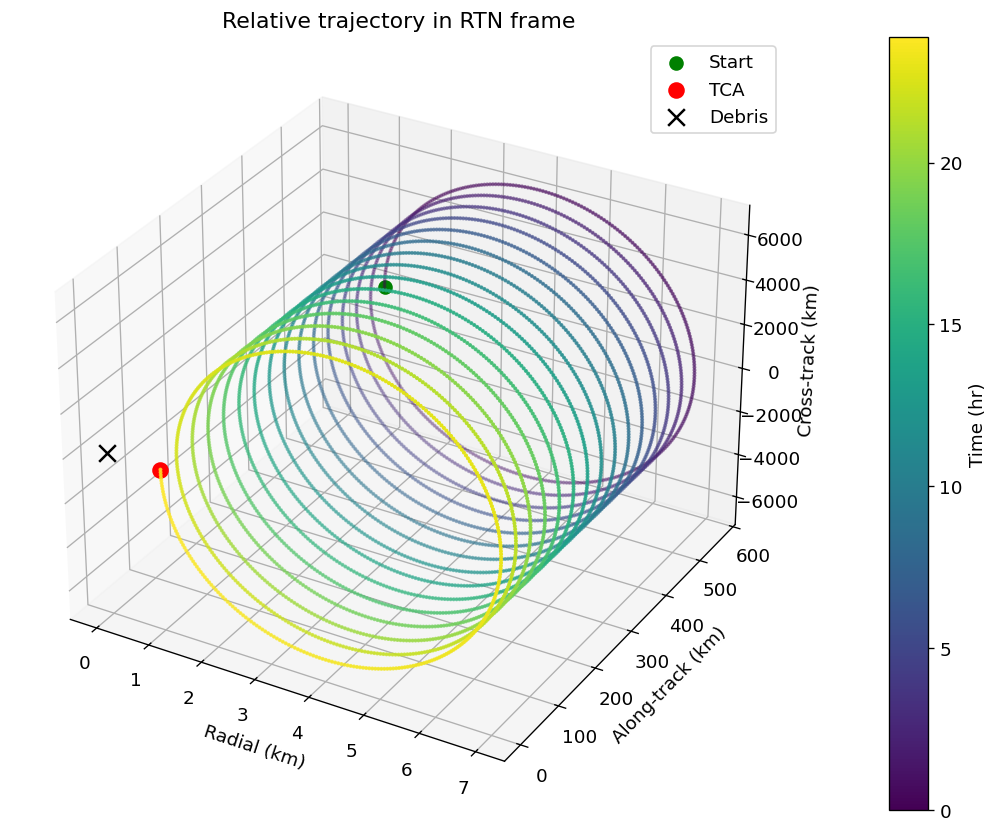

In [14]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

r, t, n = states[:, 0]/1e3, states[:, 1]/1e3, states[:, 2]/1e3

# Color trajectory by time
sc = ax.scatter(r, t, n, c=t_eval/3600, cmap='viridis', s=2)
plt.colorbar(sc, ax=ax, label='Time (hr)', pad=0.1)

# Mark start, TCA, end
ax.scatter(*states[0, :3]/1e3, color='green', s=60, zorder=5, label='Start')
idx_tca = np.argmin(distances)
ax.scatter(*states[idx_tca, :3]/1e3, color='red', s=80, zorder=5, label='TCA')

# Primary (debris) at origin
ax.scatter(0, 0, 0, color='black', s=100, marker='x', zorder=5, label='Debris')

ax.set_xlabel('Radial (km)')
ax.set_ylabel('Along-track (km)')
ax.set_zlabel('Cross-track (km)')
ax.set_title('Relative trajectory in RTN frame')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/01_rtn_trajectory.png', dpi=150)
plt.show()

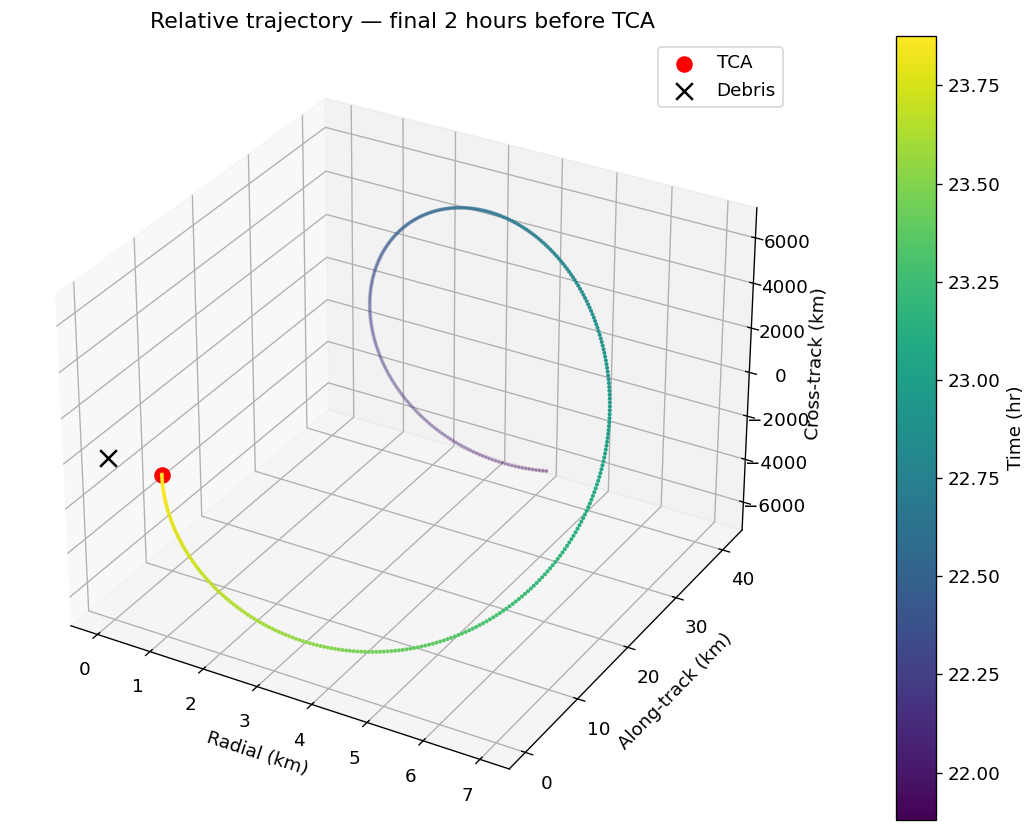

In [17]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# filter to last 2 hours before TCA
mask = t_eval > (scenario.t_horizon - 2*3600)

r = states[mask, 0]/1e3
t = states[mask, 1]/1e3
n = states[mask, 2]/1e3
t_masked = t_eval[mask]

# Color trajectory by time
sc = ax.scatter(r, t, n, c=t_masked/3600, cmap='viridis', s=2)
plt.colorbar(sc, ax=ax, label='Time (hr)', pad=0.1)

# Mark TCA
idx_tca = np.argmin(distances)
ax.scatter(*states[idx_tca, :3]/1e3, color='red', s=80, zorder=5, label='TCA')

# Debris at origin
ax.scatter(0, 0, 0, color='black', s=100, marker='x', zorder=5, label='Debris')

ax.set_xlabel('Radial (km)')
ax.set_ylabel('Along-track (km)')
ax.set_zlabel('Cross-track (km)')
ax.set_title('Relative trajectory — final 2 hours before TCA')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/01_rtn_trajectory_zoom.png', dpi=150)
plt.show()

## 5. Next Steps

- **Notebook 02** — compute the BRT over the relative state space using the HJ PDE
- **Notebook 03** — integrate covariance over BRT to produce Pc(t)
- **Notebook 04** — validate HCW against brahe full two-body propagation
